In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

files = {
    "Native": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/native_one.csv",
    "SEV": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/sev_one.csv"
}
#CSV format:
#Matrix,Cores,Run,Type,Iteration,Runtime,Gflops
all_data = []
for name, path in files.items():
    df = pd.read_csv(path,index_col=False)
    df['Environment'] = name 
    all_data.append(df)

df = pd.concat(all_data, ignore_index=True)
df_iter=df[df['Type'] == 'ITER']
df_io=df[df['Type'] == 'IO_LOAD']

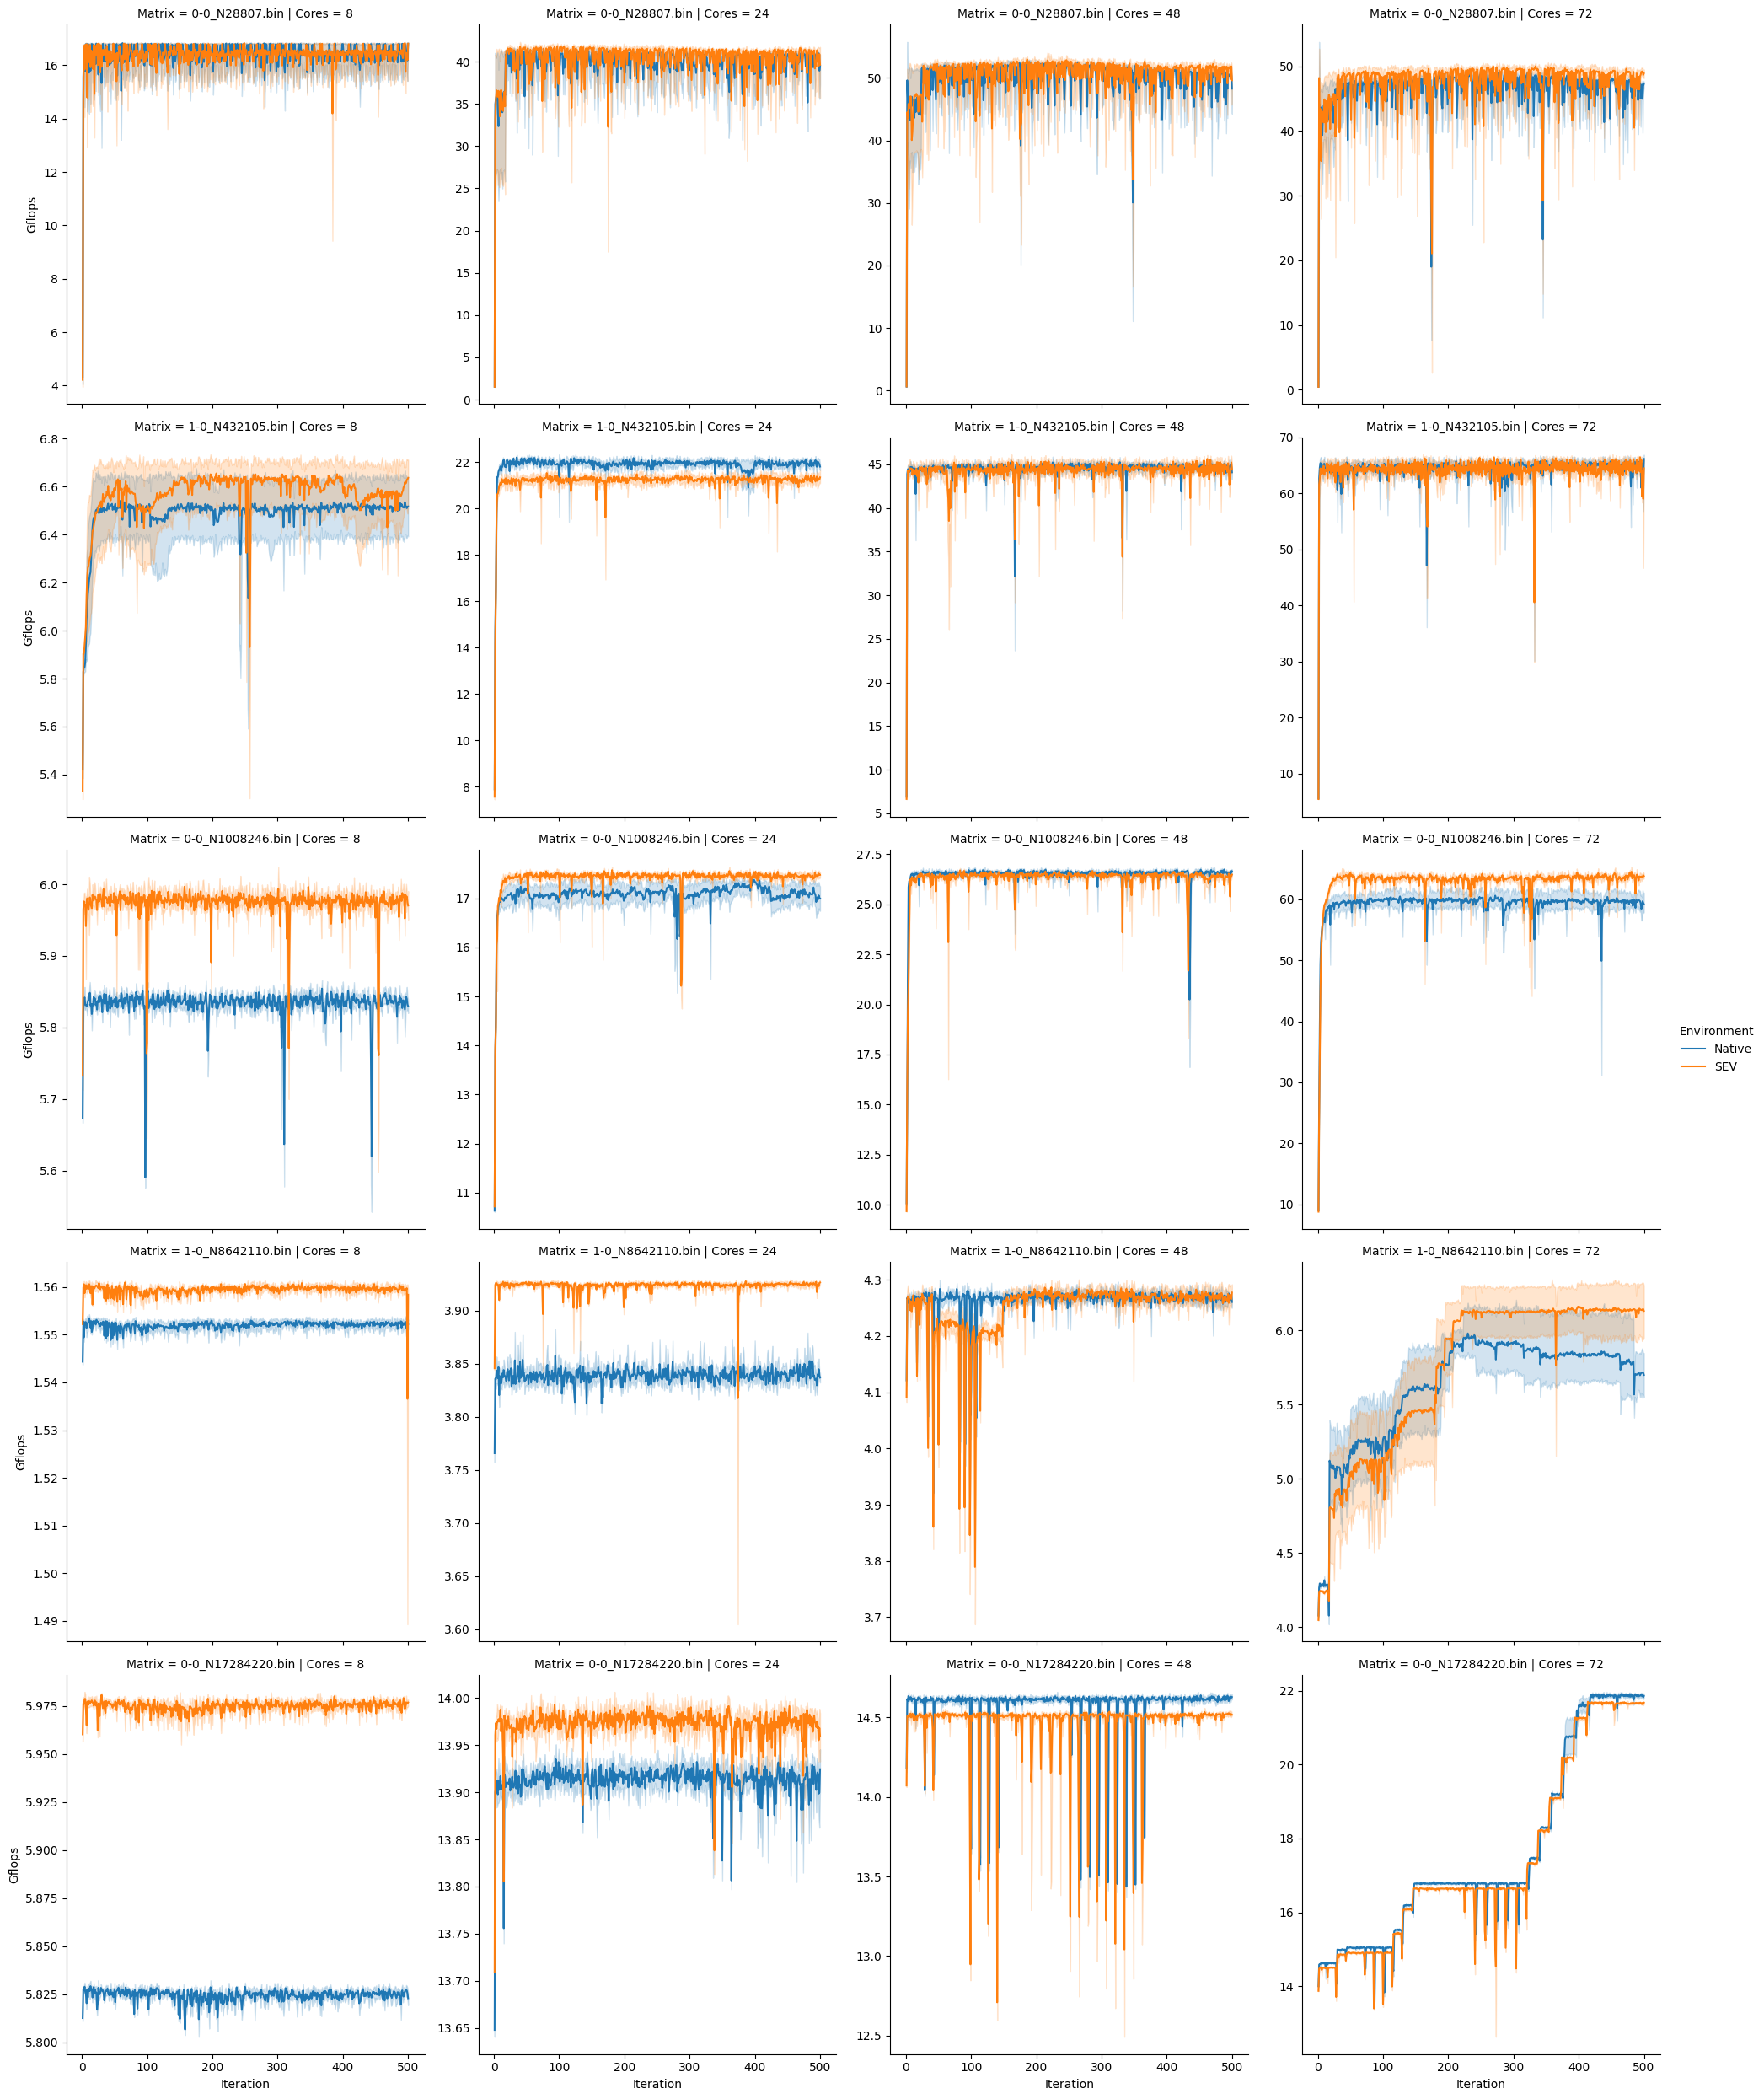

In [2]:
g = sns.relplot(
    data=df_iter, 
    x='Iteration', 
    y='Gflops', 
    hue='Environment',      # Falls du mehrere Matrizen hast
    col='Cores',       # Pro Thread-Count eine eigene Spalte
	row='Matrix',       # Pro Matrix eine eigene Zeile
    kind='line', 
    facet_kws={'sharey': False} # WICHTIG: Erlaubt eigene Y-Achsen pro Plot
)